In [4]:
from rnn_from_scratch import *
from builder_rnn_keras import *

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, zipfile, shutil, json, re, time, random, math
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu
    from nltk.translate.meteor_score import meteor_score
    HAS_NLTK = True
except Exception as e:
    HAS_NLTK = False
    print("NLTK belum tersedia, METEOR akan pakai fallback sederhana:", e)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Set path dataset

In [6]:
from pathlib import Path

BASE_DIR = Path("../../")
DATASET_DIR = BASE_DIR / "data" / "rnn & lstm"

IMAGE_DIR = DATASET_DIR / "Images"
CAPTION_FILE = DATASET_DIR / "captions.txt"

print(IMAGE_DIR)
print(CAPTION_FILE)

ARTIFACT_DIR = Path("artifacts_rnn")
FEATURE_DIR = ARTIFACT_DIR / "features"
MODEL_DIR = ARTIFACT_DIR / "models"
RESULT_DIR = ARTIFACT_DIR / "results"

for d in [ARTIFACT_DIR, FEATURE_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

..\..\data\rnn & lstm\Images
..\..\data\rnn & lstm\captions.txt


## 2. Load dan cek captions.txt

In [ ]:
captions_df = pd.read_csv(CAPTION_FILE)
captions_df.columns = [c.strip().lower() for c in captions_df.columns]

print(captions_df.head())
print(captions_df.shape)
print(captions_df.columns)

assert "image" in captions_df.columns and "caption" in captions_df.columns

captions_df["image"] = captions_df["image"].astype(str).str.strip()
captions_df["caption"] = captions_df["caption"].astype(str).str.strip()

available_images = set(p.name for p in IMAGE_DIR.glob("*.jpg"))
captions_df = captions_df[captions_df["image"].isin(available_images)].reset_index(drop=True)

print("Jumlah caption setelah filter:", len(captions_df))
print("Jumlah unique image:", captions_df["image"].nunique())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
(40455, 2)
Index(['image', 'caption'], dtype='object')
Jumlah caption setelah filter: 40455
Jumlah unique image: 8091


## 3. Split image 6000 / 1000 / 1000

In [ ]:
unique_images = sorted(captions_df["image"].unique())
random.Random(SEED).shuffle(unique_images)

train_imgs = set(unique_images[:6000])
val_imgs = set(unique_images[6000:7000])
test_imgs = set(unique_images[7000:8000])

print(len(train_imgs), len(val_imgs), len(test_imgs))

train_df = captions_df[captions_df["image"].isin(train_imgs)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_imgs)].reset_index(drop=True)
test_df = captions_df[captions_df["image"].isin(test_imgs)].reset_index(drop=True)

print("train captions:", train_df.shape)
print("val captions:", val_df.shape)
print("test captions:", test_df.shape)

6000 1000 1000
train captions: (30000, 2)
val captions: (5000, 2)
test captions: (5000, 2)


## 4. Preprocessing caption dan vocabulary

In [ ]:
PAD_TOKEN = "<pad>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

def clean_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

word_freq = {}
for cap in train_df["clean_caption"]:
    for w in cap.split():
        word_freq[w] = word_freq.get(w, 0) + 1

MIN_FREQ = 5
vocab_words = sorted([w for w, f in word_freq.items() if f >= MIN_FREQ])

idx_to_word = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN] + vocab_words
word_to_idx = {w: i for i, w in enumerate(idx_to_word)}

PAD_ID = word_to_idx[PAD_TOKEN]
START_ID = word_to_idx[START_TOKEN]
END_ID = word_to_idx[END_TOKEN]
UNK_ID = word_to_idx[UNK_TOKEN]

VOCAB_SIZE = len(word_to_idx)

lengths = train_df["clean_caption"].apply(lambda x: len(x.split()) + 2)
MAX_CAPTION_LEN = int(np.percentile(lengths, 95))
MAX_CAPTION_LEN = max(MAX_CAPTION_LEN, 8)
MAX_INPUT_LEN = MAX_CAPTION_LEN - 1

print("VOCAB_SIZE:", VOCAB_SIZE)
print("MAX_CAPTION_LEN:", MAX_CAPTION_LEN)
print("MAX_INPUT_LEN:", MAX_INPUT_LEN)

with open(ARTIFACT_DIR / "word_to_idx.json", "w") as f:
    json.dump(word_to_idx, f)

with open(ARTIFACT_DIR / "idx_to_word.json", "w") as f:
    json.dump({str(i): w for i, w in enumerate(idx_to_word)}, f)

VOCAB_SIZE: 2564
MAX_CAPTION_LEN: 20
MAX_INPUT_LEN: 19


In [10]:
def encode_caption(clean_text: str):
    words = clean_text.split()
    ids = [word_to_idx.get(w, UNK_ID) for w in words]

    full = [START_ID] + ids + [END_ID]

    input_ids = full[:-1][:MAX_INPUT_LEN]
    target_ids = full[1:][:MAX_INPUT_LEN]

    input_ids = input_ids + [PAD_ID] * (MAX_INPUT_LEN - len(input_ids))
    target_ids = target_ids + [PAD_ID] * (MAX_INPUT_LEN - len(target_ids))

    return np.array(input_ids, dtype=np.int32), np.array(target_ids, dtype=np.int32)

sample_inp, sample_tgt = encode_caption(train_df.iloc[0]["clean_caption"])

print(sample_inp.shape, sample_tgt.shape)
print("input :", [idx_to_word[i] for i in sample_inp[:10]])
print("target:", [idx_to_word[i] for i in sample_tgt[:10]])

(19,) (19,)
input : ['<start>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up']
target: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a']


## 5. Feature extraction CNN encoder

In [11]:
FEATURE_PATH = FEATURE_DIR / "flickr8k_inception_features.npy"
FEATURE_DIM = 2048
IMG_SIZE = (299, 299)

def load_and_preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

def extract_features_inception(image_names, batch_size=64):
    encoder = InceptionV3(include_top=False, weights="imagenet", pooling="avg")
    encoder.trainable = False

    features = {}
    image_names = list(image_names)

    for start in range(0, len(image_names), batch_size):
        batch_names = image_names[start:start+batch_size]
        batch_arr = np.vstack([load_and_preprocess_image(IMAGE_DIR / name) for name in batch_names])
        batch_feat = encoder.predict(batch_arr, verbose=0)

        for name, feat in zip(batch_names, batch_feat):
            features[name] = feat.astype(np.float32)

        if start % (batch_size * 10) == 0:
            print(f"Extracted {start + len(batch_names)} / {len(image_names)}")

    return features

if FEATURE_PATH.exists():
    features = np.load(FEATURE_PATH, allow_pickle=True).item()
    print("Loaded features:", len(features))
else:
    all_used_imgs = sorted(list(train_imgs | val_imgs | test_imgs))
    features = extract_features_inception(all_used_imgs, batch_size=64)
    np.save(FEATURE_PATH, features)
    print("Saved:", FEATURE_PATH)

FEATURE_DIM = len(next(iter(features.values())))
print("FEATURE_DIM:", FEATURE_DIM)

Loaded features: 8000
FEATURE_DIM: 2048


## 6. Build array training/validation/test

In [12]:
def build_arrays(df):
    n = len(df)

    X_feat = np.zeros((n, FEATURE_DIM), dtype=np.float32)
    X_tok = np.zeros((n, MAX_INPUT_LEN), dtype=np.int32)
    y = np.zeros((n, MAX_INPUT_LEN), dtype=np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        image_name = row.image
        clean_text = row.clean_caption

        inp, tgt = encode_caption(clean_text)

        X_feat[i] = features[image_name]
        X_tok[i] = inp
        y[i] = tgt

    sample_weight = (y != PAD_ID).astype(np.float32)

    return X_feat, X_tok, y, sample_weight

X_train_feat, X_train_tok, y_train, sw_train = build_arrays(train_df)
X_val_feat, X_val_tok, y_val, sw_val = build_arrays(val_df)
X_test_feat, X_test_tok, y_test, sw_test = build_arrays(test_df)

print(X_train_feat.shape, X_train_tok.shape, y_train.shape, sw_train.shape)
print(X_val_feat.shape, X_val_tok.shape, y_val.shape, sw_val.shape)
print(X_test_feat.shape, X_test_tok.shape, y_test.shape, sw_test.shape)

(30000, 2048) (30000, 19) (30000, 19) (30000, 19)
(5000, 2048) (5000, 19) (5000, 19) (5000, 19)
(5000, 2048) (5000, 19) (5000, 19) (5000, 19)


## 7. Build model Keras SimpleRNN

In [ ]:
def masked_sparse_categorical_crossentropy(y_true, y_pred):
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        reduction="none"
    )

    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), dtype=loss.dtype)

    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

test_model = build_keras_rnn_decoder(FEATURE_DIM, VOCAB_SIZE, MAX_INPUT_LEN)
test_model.summary()

Model: "rnn_decoder_1layer_256hidden"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_feature_input │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 256)       │    524,544 │ image_feature_in… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_token_input │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_as_timestep │ (None, 1, 256)    │          0 │ feature_projecti… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_embedding   │ (None, 19, 256)   │    656,384 │ caption_token_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preinject_concat    │ (None, 20, 256)   │          0 │ feature_as_times… │
│ (Concatenate)       │                   │            │ caption_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_1 (SimpleRNN)   │ (None, 20, 256)   │    131,328 │ preinject_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ remove_feature_tim… │ (None, 19, 256)   │          0 │ rnn_1[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vocab_output        │ (None, 19, 2564)  │    658,948 │ remove_feature_t… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,971,204 (7.52 MB)

 Trainable params: 1,971,204 (7.52 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training variasi RNN

In [ ]:
EPOCHS = 15
BATCH_SIZE = 64
EMBED_DIM = 256

experiments = []
for num_layers in [1, 2, 3]:
    for hidden_size in [128, 512]:
        experiments.append({
            "name": f"rnn_{num_layers}layer_{hidden_size}hidden",
            "num_layers": num_layers,
            "hidden_size": hidden_size,
        })

all_histories = {}
training_summary = []

callbacks = []

for exp in experiments:
    print("\n===== Training", exp["name"], "=====")

    model = build_keras_rnn_decoder(
        feature_dim=FEATURE_DIM,
        vocab_size=VOCAB_SIZE,
        max_input_len=MAX_INPUT_LEN,
        embed_dim=EMBED_DIM,
        hidden_size=exp["hidden_size"],
        num_rnn_layers=exp["num_layers"],
        learning_rate=1e-3,
        pad_id=PAD_ID,
    )

    start_time = time.time()

    history = model.fit(
        [X_train_feat, X_train_tok],
        y_train,
        validation_data=([X_val_feat, X_val_tok], y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    elapsed = time.time() - start_time

    save_path = MODEL_DIR / f"{exp['name']}.keras"
    model.save(save_path)

    all_histories[exp["name"]] = history.history

    training_summary.append({
        **exp,
        "epochs_ran": len(history.history["loss"]),
        "train_time_sec": elapsed,
        "best_val_loss": min(history.history["val_loss"]),
        "final_train_loss": history.history["loss"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "model_path": str(save_path),
    })

    with open(RESULT_DIR / "rnn_histories.json", "w") as f:
        json.dump(all_histories, f, indent=2)

training_summary_df = pd.DataFrame(training_summary)
training_summary_df.to_csv(RESULT_DIR / "rnn_training_summary.csv", index=False)
training_summary_df


===== Training rnn_1layer_128hidden =====


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - loss: 4.3142 - val_loss: 3.6820
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 3.5043 - val_loss: 3.3850
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 3.2618 - val_loss: 3.2457
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 3.1202 - val_loss: 3.1669
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 3.0191 - val_loss: 3.1133
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 2.9423 - val_loss: 3.0767
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 2.8764 - val_loss: 3.0540
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 2.8226 - val_loss: 3.0369
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 2.7773 - val_loss: 3.0219
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 2.7330 - val_loss: 3.0134
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 2.6948 - val_loss: 3.0172
Epoch 12/15
469/469 ━━━━━━━━━━

,name,num_layers,hidden_size,epochs_ran,train_time_sec,best_val_loss,final_train_loss,final_val_loss,model_path
0,rnn_1layer_128hidden,1,128,15,337.711426,3.010572,2.573920,3.014172,artifacts_rnn\models\rnn_1layer_128hidden.keras
1,rnn_1layer_512hidden,1,512,15,981.580548,2.986253,2.057045,3.145313,artifacts_rnn\models\rnn_1layer_512hidden.keras
2,rnn_2layer_128hidden,2,128,15,354.982794,3.029814,2.566877,3.041776,artifacts_rnn\models\rnn_2layer_128hidden.keras
3,rnn_2layer_512hidden,2,512,15,1190.946996,3.042489,2.226032,3.123565,artifacts_rnn\models\rnn_2layer_512hidden.keras
4,rnn_3layer_128hidden,3,128,15,385.784912,3.027751,2.597072,3.039613,artifacts_rnn\models\rnn_3layer_128hidden.keras
5,rnn_3layer_512hidden,3,512,15,1381.414855,3.076263,2.376824,3.133212,artifacts_rnn\models\rnn_3layer_512hidden.keras


## 9. Plot training loss dan validation loss

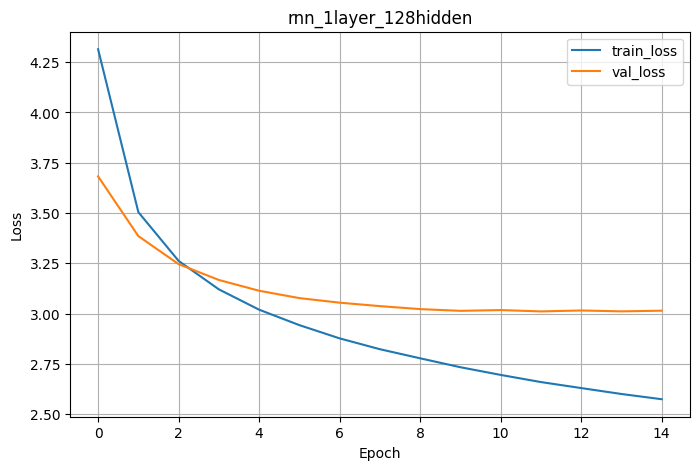

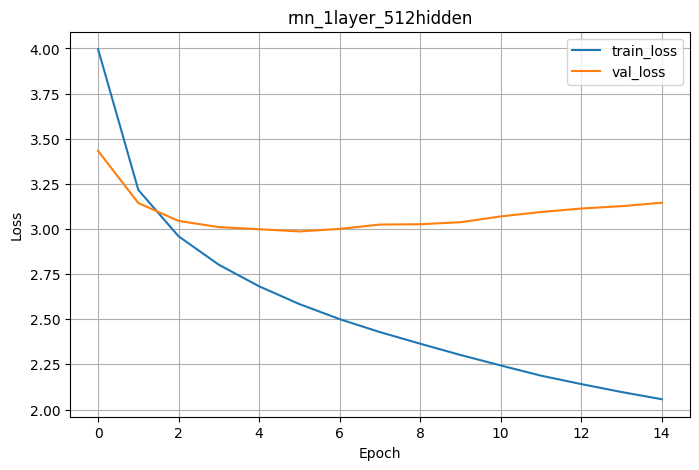

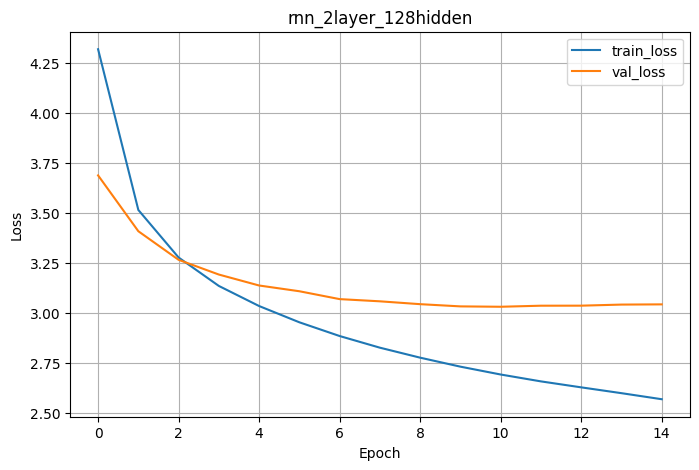

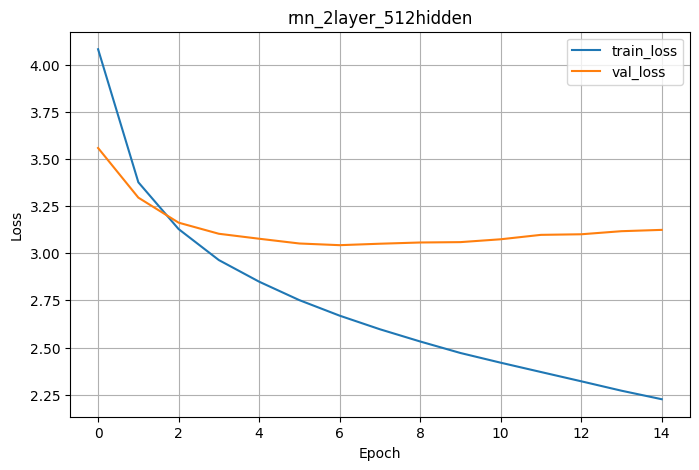

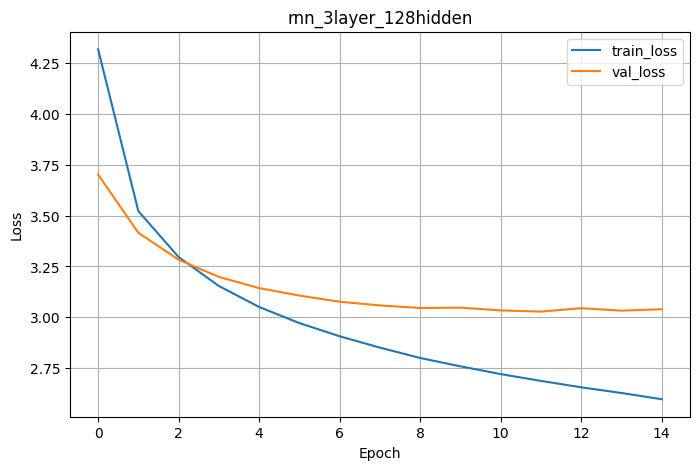

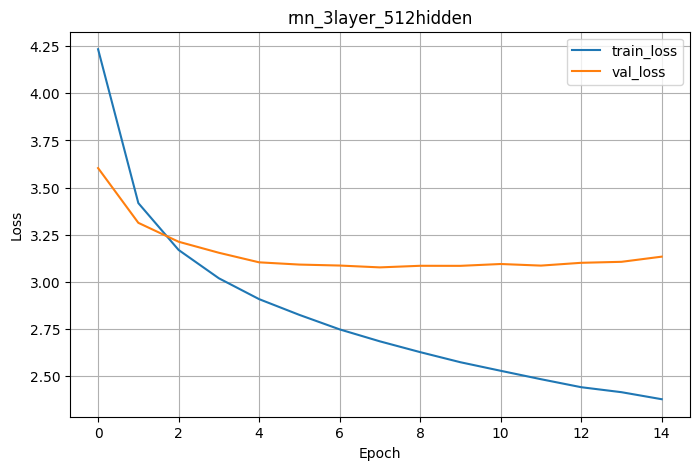

In [15]:
def plot_history(history_dict, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="train_loss")
    plt.plot(history_dict["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

for name, hist in all_histories.items():
    plot_history(hist, name)

## 10. Greedy decoding Keras

In [ ]:
idx_to_word_dict = {i: w for i, w in enumerate(idx_to_word)}
word_to_idx_dict = word_to_idx

def ids_to_sentence(ids):
    words = []

    for idx in ids:
        idx = int(idx)
        w = idx_to_word_dict.get(idx, UNK_TOKEN)

        if w in [PAD_TOKEN, START_TOKEN, UNK_TOKEN]:
            continue

        if w == END_TOKEN:
            break

        words.append(w)

    return " ".join(words)


def generate_caption_keras(model, image_feature, max_caption_len=20):
    tokens = [START_ID]
    generated = []

    for _ in range(max_caption_len):
        inp = tokens[-MAX_INPUT_LEN:]
        inp = inp + [PAD_ID] * (MAX_INPUT_LEN - len(inp))
        inp = np.array(inp, dtype=np.int32)[None, :]

        feat = image_feature.astype(np.float32)[None, :]
        probs = model.predict([feat, inp], verbose=0)

        t = min(len(tokens) - 1, probs.shape[1] - 1)

        next_prob = probs[0, t, :].copy()
        next_prob[PAD_ID] = -1.0
        next_prob[START_ID] = -1.0
        next_prob[UNK_ID] = -1.0

        next_id = int(np.argmax(next_prob))

        if next_id == END_ID:
            break

        generated.append(next_id)
        tokens.append(next_id)

    return ids_to_sentence(generated)


summary_df = pd.read_csv(RESULT_DIR / "rnn_training_summary.csv")
best_row = summary_df.sort_values("best_val_loss").iloc[0]
best_model_path = best_row["model_path"]

best_keras_model = tf.keras.models.load_model(
    best_model_path,
    compile=False,
    safe_mode=False
)

print("Best model:", best_row.to_dict())

sample_image = test_df.iloc[0]["image"]
print("Image:", sample_image)
print("Generated:", generate_caption_keras(best_keras_model, features[sample_image], max_caption_len=20))
print("Ground truth:")
print(test_df[test_df["image"] == sample_image]["caption"].tolist())

Best model: {'name': 'rnn_1layer_512hidden', 'num_layers': 1, 'hidden_size': 512, 'epochs_ran': 15, 'train_time_sec': 981.580548286438, 'best_val_loss': 2.986253499984741, 'final_train_loss': 2.057044982910156, 'final_val_loss': 3.145312547683716, 'model_path': 'artifacts_rnn\\models\\rnn_1layer_512hidden.keras'}
Image: 1003163366_44323f5815.jpg
Generated: two people are playing in a yard
Ground truth:
['A man lays on a bench while his dog sits by him .', 'A man lays on the bench to which a white dog is also tied .', 'a man sleeping on a bench outside with a white and black dog sitting next to him .', 'A shirtless man lies on a park bench with his dog .', 'man laying on bench holding leash of dog sitting on ground']


## 11. Evaluasi BLEU-4 dan METEOR

In [19]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to C:\Users\Anella
[nltk_data]     Utari\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Anella
[nltk_data]     Utari\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.translate.meteor_score import meteor_score

def get_references_for_image(df, image_name):
    refs = []
    for cap in df[df["image"] == image_name]["clean_caption"]:
        refs.append(cap.split())
    return refs

def compute_meteor(references, hypothesis):
    try:
        return meteor_score(references, hypothesis)
    except Exception:
        return 0.0

def evaluate_caption_model_keras(model, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval["image"].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()

    for name in eval_images:
        pred = generate_caption_keras(
            model,
            features[name],
            max_caption_len=max_caption_len
        )

        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)

        meteor_scores.append(compute_meteor(refs, hyp))

    elapsed = time.time() - start

    smoothie = SmoothingFunction().method4

    bleu4 = corpus_bleu(
        references_all,
        hypotheses_all,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return {
        "BLEU_4": bleu4,
        "METEOR": float(np.mean(meteor_scores)),
        "time_sec": elapsed,
        "n_images": len(eval_images),
    }

eval_rows = []

for _, row in summary_df.iterrows():
    print("Evaluating:", row["name"])

    model = tf.keras.models.load_model(
        row["model_path"],
        compile=False,
        safe_mode=False
    )

    metrics = evaluate_caption_model_keras(
        model,
        test_df,
        max_images=1000,
        max_caption_len=20
    )

    eval_rows.append({**row.to_dict(), **metrics})

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(RESULT_DIR / "rnn_test_metrics_keras.csv", index=False)

eval_df.sort_values(["BLEU_4", "METEOR"], ascending=False)

Evaluating: rnn_1layer_128hidden
Evaluating: rnn_1layer_512hidden
Evaluating: rnn_2layer_128hidden
Evaluating: rnn_2layer_512hidden
Evaluating: rnn_3layer_128hidden
Evaluating: rnn_3layer_512hidden


,name,num_layers,hidden_size,epochs_ran,train_time_sec,best_val_loss,final_train_loss,final_val_loss,model_path,BLEU_4,METEOR,time_sec,n_images
1,rnn_1layer_512hidden,1,512,15,981.580548,2.986253,2.057045,3.145313,artifacts_rnn\models\rnn_1layer_512hidden.keras,0.126361,0.315336,1461.303490,1000
5,rnn_3layer_512hidden,3,512,15,1381.414855,3.076263,2.376824,3.133212,artifacts_rnn\models\rnn_3layer_512hidden.keras,0.124078,0.313072,2161.439607,1000
3,rnn_2layer_512hidden,2,512,15,1190.946996,3.042489,2.226032,3.123565,artifacts_rnn\models\rnn_2layer_512hidden.keras,0.121389,0.313884,1637.886432,1000
2,rnn_2layer_128hidden,2,128,15,354.982794,3.029814,2.566877,3.041776,artifacts_rnn\models\rnn_2layer_128hidden.keras,0.121241,0.297279,1515.722858,1000
4,rnn_3layer_128hidden,3,128,15,385.784912,3.027751,2.597072,3.039613,artifacts_rnn\models\rnn_3layer_128hidden.keras,0.115450,0.304349,1863.534030,1000
0,rnn_1layer_128hidden,1,128,15,337.711426,3.010572,2.573920,3.014172,artifacts_rnn\models\rnn_1layer_128hidden.keras,0.106330,0.299688,1612.901291,1000


## 12. Load bobot Keras ke RNN from scratch NumPy

In [ ]:
from rnn_from_scratch import build_scratch_decoder_from_keras

best_row = eval_df.sort_values(["BLEU_4", "METEOR"], ascending=False).iloc[0]
best_model_path = best_row["model_path"]
best_keras_model = tf.keras.models.load_model(
    best_model_path,
    compile=False,
    safe_mode=False
)

num_layers = int(best_row["num_layers"])
layer_names = {
    "feature_projection": "feature_projection",
    "embedding": "caption_embedding",
    "rnn_layers": [f"rnn_{i+1}" for i in range(num_layers)],
    "output_dense": "vocab_output",
}

scratch_decoder = build_scratch_decoder_from_keras(
    best_keras_model,
    layer_names=layer_names,
    idx_to_word=idx_to_word_dict,
    word_to_idx=word_to_idx_dict,
)

print("Scratch decoder berhasil dibuat dari:", best_model_path)

Scratch decoder berhasil dibuat dari: artifacts_rnn\models\rnn_1layer_512hidden.keras


In [25]:
def generate_caption_scratch(decoder, image_feature, max_caption_len=20):
    return decoder.generate_caption(
        image_feature=image_feature.astype(np.float32),
        start_id=START_ID,
        end_id=END_ID,
        max_len=max_caption_len,
        pad_id=PAD_ID,
    )

sample_image = test_df.iloc[0]["image"]
print("Keras  :", generate_caption_keras(best_keras_model, features[sample_image], max_caption_len=20))
print("Scratch:", generate_caption_scratch(scratch_decoder, features[sample_image], max_caption_len=20))

Keras  : two people are playing in a yard
Scratch: two people are playing in a yard


## 13. Evaluasi Scratch

In [26]:
def evaluate_caption_model_scratch(decoder, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval["image"].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()
    for name in eval_images:
        pred = generate_caption_scratch(decoder, features[name], max_caption_len=max_caption_len)
        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)

        if HAS_NLTK:
            try:
                meteor_scores.append(meteor_score(refs, hyp))
            except Exception:
                meteor_scores.append(meteor_fallback(refs, hyp))
        else:
            meteor_scores.append(meteor_fallback(refs, hyp))

    elapsed = time.time() - start

    if HAS_NLTK:
        bleu4 = corpus_bleu(
            references_all,
            hypotheses_all,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=SmoothingFunction().method4
        )
    else:
        bleu4 = np.nan

    return {
        "BLEU_4": bleu4,
        "METEOR": float(np.mean(meteor_scores)),
        "time_sec": elapsed,
        "n_images": len(eval_images),
    }

scratch_metrics = evaluate_caption_model_scratch(scratch_decoder, test_df, max_images=1000, max_caption_len=20)
keras_metrics = evaluate_caption_model_keras(best_keras_model, test_df, max_images=1000, max_caption_len=20)

comparison_df = pd.DataFrame([
    {"implementation": "Keras", **keras_metrics},
    {"implementation": "Scratch NumPy", **scratch_metrics},
])
comparison_df.to_csv(RESULT_DIR / "rnn_keras_vs_scratch.csv", index=False)
comparison_df

,implementation,BLEU_4,METEOR,time_sec,n_images
0,Keras,0.126361,0.315336,1468.481886,1000
1,Scratch NumPy,0.126414,0.315624,37.674268,1000


## 14. Pengaruh panjang maksimum caption

In [27]:
max_len_rows = []
for max_len in [10, 20, 30]:
    print("max_caption_len:", max_len)
    metrics = evaluate_caption_model_scratch(
        scratch_decoder,
        test_df,
        max_images=1000,
        max_caption_len=max_len
    )
    max_len_rows.append({"max_caption_len": max_len, **metrics})

max_len_df = pd.DataFrame(max_len_rows)
max_len_df.to_csv(RESULT_DIR / "rnn_max_caption_len.csv", index=False)
max_len_df

max_caption_len: 10
max_caption_len: 20
max_caption_len: 30


,max_caption_len,BLEU_4,METEOR,time_sec,n_images
0,10,0.134262,0.309687,12.344786,1000
1,20,0.126414,0.315624,14.820510,1000
2,30,0.126400,0.315621,16.057022,1000


## 15. Qualitative analysis 10 contoh gambar

In [ ]:
def sentence_bleu4(refs, hyp):
    if not HAS_NLTK:
        return np.nan
    return sentence_bleu(
        refs,
        hyp,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=SmoothingFunction().method4
    )

qual_rows = []
for name in sorted(test_df["image"].unique())[:200]:
    pred = generate_caption_scratch(scratch_decoder, features[name], max_caption_len=20)
    hyp = pred.split()
    refs = get_references_for_image(test_df, name)

    qual_rows.append({
        "image": name,
        "pred_caption_rnn": pred,
        "ground_truth": " | ".join(test_df[test_df["image"] == name]["caption"].tolist()),
        "sentence_bleu4": sentence_bleu4(refs, hyp)
    })

qual_df = pd.DataFrame(qual_rows).sort_values("sentence_bleu4", ascending=False)

top = qual_df.head(4)
mid = qual_df.iloc[len(qual_df)//2:len(qual_df)//2+3]
low = qual_df.tail(3)
qual_sample_df = pd.concat([top, mid, low]).reset_index(drop=True)

qual_sample_df.to_csv(RESULT_DIR / "rnn_qualitative_examples.csv", index=False)
qual_sample_df

,image,pred_caption_rnn,ground_truth,sentence_bleu4
0,1019077836_6fc9b15408.jpg,a dog is playing with a ball,A brown dog chases the water from a sprinkler ...,0.809107
1,1563731247_7f21d8bec0.jpg,two children are playing in a yard,A child plays on the ground in a pile of leave...,0.809107
2,1176580356_9810d877bf.jpg,a dog is jumping up to catch a ball,A big dog catches a ball on his nose | A brown...,0.803428
3,2256218522_53b92bcbb2.jpg,a black and white dog is running through a gra...,A black and white dog is running through the s...,0.638194
4,1473618073_7db56a5237.jpg,two children playing on a jungle gym,A boy on a green plastic swing . | A little bo...,0.081939
5,1075881101_d55c46bece.jpg,two people are seated on a bus,a boy cleans the bubbles off his face . | A bo...,0.081939
6,2092870249_90e3f1855b.jpg,a man is standing on a wooden bench reading a ...,A man lies on a street with his head and shoul...,0.081240
7,1732217138_aa0199ef87.jpg,a man in a black shirt is standing in front of...,The couple eat their meal outside . | two peop...,0.019731
8,1003163366_44323f5815.jpg,two people are playing in a yard,A man lays on a bench while his dog sits by hi...,0.018274
9,195962790_3380aea352.jpg,two dogs run through water,A woman in a purple shirt and a brown puppy si...,0.000000


Image: 1019077836_6fc9b15408.jpg
BLEU-4: 0.8091067115702212
RNN prediction: a dog is playing with a ball
Ground truth: A brown dog chases the water from a sprinkler on a lawn . | a brown dog plays with the hose . | A brown dog running on a lawn near a garden hose | A dog is playing with a hose . | Large brown dog running away from the sprinkler in the grass .


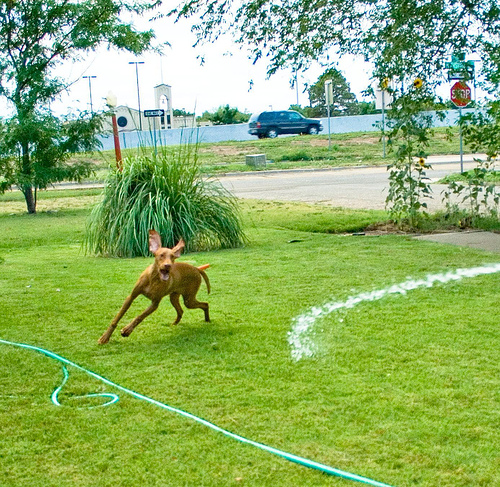

Image: 1563731247_7f21d8bec0.jpg
BLEU-4: 0.8091067115702212
RNN prediction: two children are playing in a yard
Ground truth: A child plays on the ground in a pile of leaves . | a little girl is playing in the hay . | Little girl buried in hay throwing hay around at a lady . | The girls play in the pumpkin patch . | Two children are playing in a pile of hay with the sun shining overhead .


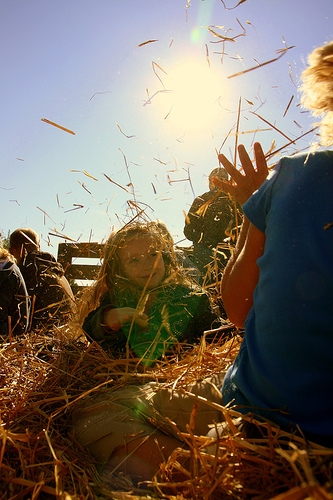

Image: 1176580356_9810d877bf.jpg
BLEU-4: 0.8034284189446518
RNN prediction: a dog is jumping up to catch a ball
Ground truth: A big dog catches a ball on his nose | A brown and black dog is jumping to catch a red ball . | A brown and black dog jumps for a red ball . | Dog jumps to get orange ball on his head . | The brown and black dog is jumping up to catch a red ball .


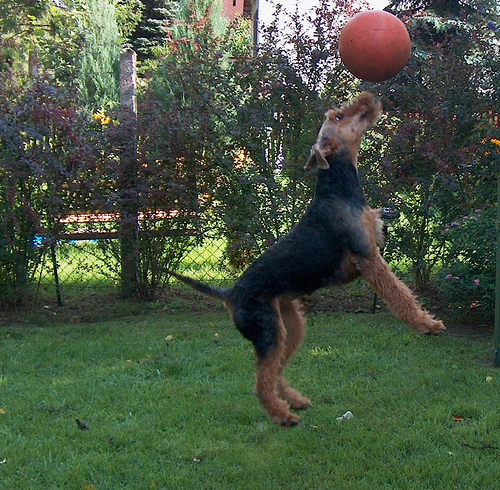

Image: 2256218522_53b92bcbb2.jpg
BLEU-4: 0.6381941796682009
RNN prediction: a black and white dog is running through a grassy field
Ground truth: A black and white dog is running through the sand at a beach . | A black and white dog playing in the sand . | A dog bounding across the sandy landscape in front of people watching . | A dog lunges across a beach . | Black dog running across dirt .


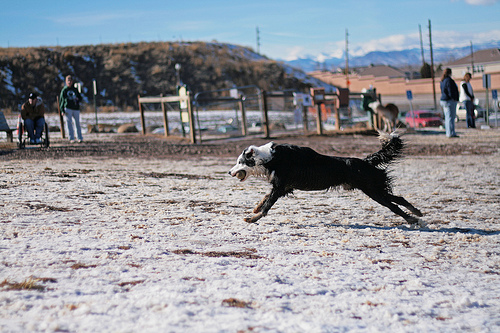

Image: 1473618073_7db56a5237.jpg
BLEU-4: 0.081939171811711
RNN prediction: two children playing on a jungle gym
Ground truth: A boy on a green plastic swing . | A little boy sitting on a green swing . | A smiling boy plays on a green plastic swing-toy . | Boy swinging on a swing set . | Little boy riding on green swing in a playground .


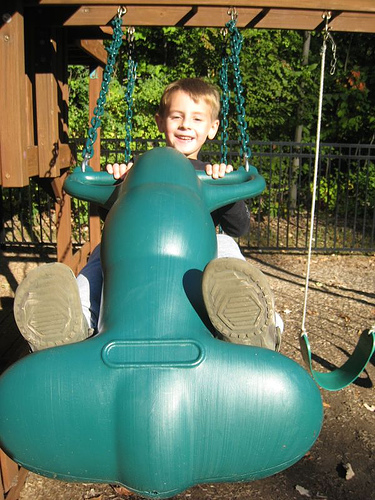

Image: 1075881101_d55c46bece.jpg
BLEU-4: 0.081939171811711
RNN prediction: two people are seated on a bus
Ground truth: a boy cleans the bubbles off his face . | A boy covered in suds has his face wiped clean . | A boy is covered in bubbles . | A child covered in foam is climbing on a black inflatable ramp . | A person covered in soapy water is getting cleaned off .


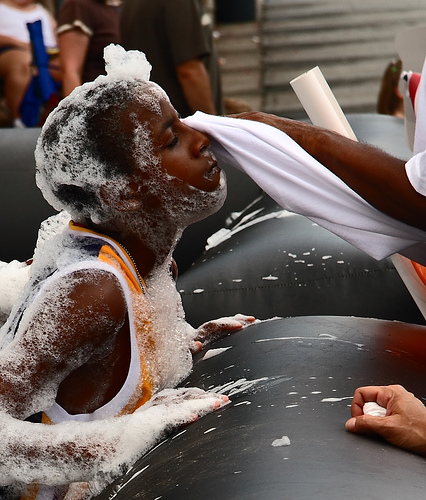

Image: 2092870249_90e3f1855b.jpg
BLEU-4: 0.08124031954514328
RNN prediction: a man is standing on a wooden bench reading a book
Ground truth: A man lies on a street with his head and shoulders under a parked car that is jacked up . | A man looks under a car on a wet street . | A man works on a car . | A person lies half under a car , face-down . | A person underneath a car with a jack .


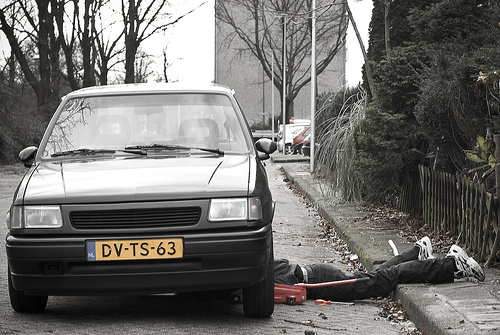

Image: 1732217138_aa0199ef87.jpg
BLEU-4: 0.019730657693620934
RNN prediction: a man in a black shirt is standing in front of a crowd of people
Ground truth: The couple eat their meal outside . | two people sit on a bench . | Two people sitting , facing away , with dreadlocks . | Two people with dreadlocks . | Two people with dreadlocks sit on a wooden bench .


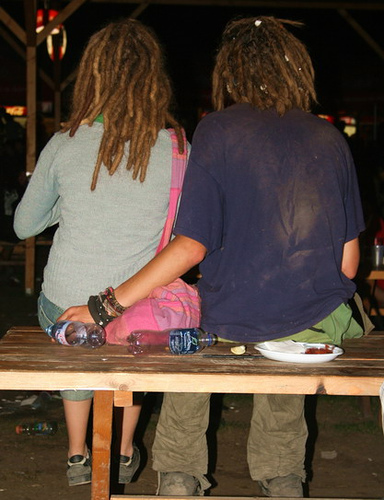

Image: 1003163366_44323f5815.jpg
BLEU-4: 0.018273910508530698
RNN prediction: two people are playing in a yard
Ground truth: A man lays on a bench while his dog sits by him . | A man lays on the bench to which a white dog is also tied . | a man sleeping on a bench outside with a white and black dog sitting next to him . | A shirtless man lies on a park bench with his dog . | man laying on bench holding leash of dog sitting on ground


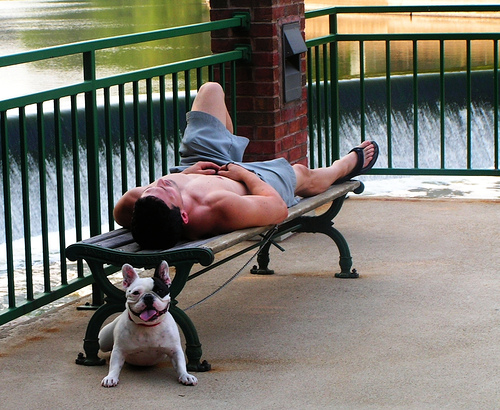

Image: 195962790_3380aea352.jpg
BLEU-4: 0.0
RNN prediction: two dogs run through water
Ground truth: A woman in a purple shirt and a brown puppy sit near a fountain | A woman sits by the pool with a dog while another dog is nearby . | A woman sits with her feet in a shallow pool and looks at a puppy . | While the humans put their feet into the fountain , the puppy on the side with his master checks out the muzzle leash on the large rottweiler . | Woman and dog cooling off at fountain


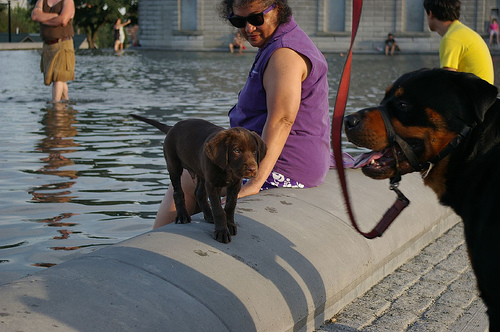

In [29]:
from IPython.display import display, Image as IPImage

for _, row in qual_sample_df.iterrows():
    print("=" * 80)
    print("Image:", row["image"])
    print("BLEU-4:", row["sentence_bleu4"])
    print("RNN prediction:", row["pred_caption_rnn"])
    print("Ground truth:", row["ground_truth"])
    display(IPImage(filename=str(IMAGE_DIR / row["image"]), width=300))